<div style="font-size: 16px;">

# Introduction

Fashion MNIST is a dataset consisting of 70,000 grayscale images of clothing items divided into 10 categories, such as T-shirts, trousers, dresses, shoes, and bags. Each image has a resolution of 28×28 pixels and is assigned to one class.

The goal of this project is to build and evaluate convolutional neural networks (CNNs) for image classification on the Fashion MNIST dataset. Different CNN architectures are trained and compared to investigate how model complexity and regularization techniques affect performance.

The project includes:

- exploratory analysis of the dataset,
- development of two custom CNN architectures,
- experiments with regularization techniques such as dropout and early stopping,
- evaluation of model performance using validation and test data,
- comparison of custom CNN models with a pretrained VGG16 model using transfer learning.

Models are compared using validation loss and validation accuracy, while the final selected model is evaluated on the test set to estimate its performance on unseen data.

In [1]:
import numpy as np 
import pandas as pd 
import os

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision import models
from torchvision.models import VGG16_Weights
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import cv2
import copy

In [2]:
import random

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
root_path = "/kaggle/input"
max_depth = 8

for root, dirs, files in os.walk(root_path):
    depth = root.replace(root_path, "").count(os.sep)
    
    if depth <= max_depth:
        indent = "    " * depth
        print(f"{indent}{os.path.basename(root)}/")
    
    if depth >= max_depth:
        dirs[:] = []

input/
    datasets/
        organizations/
            zalando-research/
                fashionmnist/


In [5]:
dataset_path = "/kaggle/input/datasets/organizations/zalando-research/fashionmnist"

print(os.listdir(dataset_path))

['t10k-labels-idx1-ubyte', 't10k-images-idx3-ubyte', 'fashion-mnist_test.csv', 'fashion-mnist_train.csv', 'train-labels-idx1-ubyte', 'train-images-idx3-ubyte']


In [6]:
train_path = "/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_train.csv"
test_path = "/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 59.9 MB


In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 359.3 MB


In [9]:
train_df["label"].value_counts().sort_index()

label
0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    6000
9    6000
Name: count, dtype: int64

In [10]:
class_names = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

# Train-val split

In [11]:
train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df["label"]
)

print(train_data.shape)
print(val_data.shape)
print(test_df.shape)

(48000, 785)
(12000, 785)
(10000, 785)


# Image preprocessing

In [12]:
pixel_columns = train_data.drop("label", axis=1)

fashion_mnist_mean = pixel_columns.values.mean() / 255.0
fashion_mnist_std = pixel_columns.values.std() / 255.0

print(f"Mean: {fashion_mnist_mean:.4f}")
print(f"Std: {fashion_mnist_std:.4f}")

Mean: 0.2857
Std: 0.3525


<div style="font-size: 16px;">

* Mean and standard deviation are calculated only from the training set to avoid using information from the test or validation set during preprocessing
* In CSV files, pixels are stored as values between 0 and 255, so we divide by 255

In [13]:
transform_cnn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[fashion_mnist_mean],
        std=[fashion_mnist_std]
    )
])

transform_vgg = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

<div style="font-size: 16px;">

Two different transformations for two different models


Custom CNN
* uses the original Fashion MNIST format: 1×28×28 grayscale images.
* normalize using one mean and one standard deviation value.

VGG16
* was pretrained on ImageNet, where images are RGB and resized to 224×224.
* convert Fashion MNIST images to 3 channels, resize them, and apply ImageNet normalization.

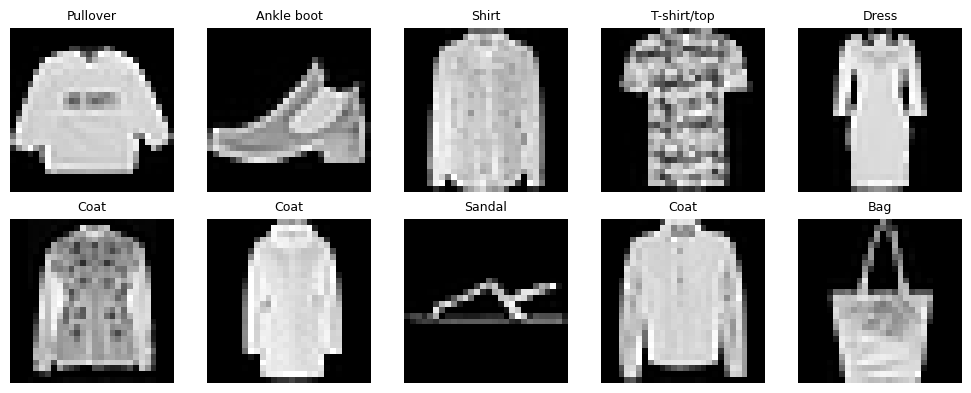

In [14]:
# reshape 28x28, 28 × 28 = 784 columns

plt.figure(figsize=(10, 4))

for i in range(10):
    image = train_df.drop("label", axis=1).iloc[i].values.reshape(28, 28)
    label = train_df["label"].iloc[i]
    
    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(class_names[label], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Custom CNN

In [15]:
class FashionMNISTCSV(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        
        self.labels = self.dataframe["label"].values
        self.images = self.dataframe.drop("label", axis=1).values

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image = self.images[idx].reshape(28, 28).astype(np.uint8)
        label = int(self.labels[idx])
        
        image = Image.fromarray(image, mode="L")
        
        if self.transform:
            image = self.transform(image)
        
        return image, label


<div style="font-size: 16px;">

### FashionMNISTCSV

* The Fashion MNIST dataset from Kaggle is stored in CSV format, not as separate image files.
* Each row contains one label and 784 pixel values.
* The 784 pixel values represent a flattened 28×28 grayscale image.
* A custom PyTorch `Dataset` class is needed to convert each CSV row into a format that can be used by a neural network.
* Inside the dataset class, labels are separated from pixel values.
* Pixel values are reshaped from a flat vector into a 28×28 image.
* The image is converted to PIL grayscale format so that `torchvision.transforms` can be applied.
* The class returns one image and one label at a time, which allows PyTorch `DataLoader` to create batches during training.

In [16]:
BATCH_SIZE = 64
EPOCHS = 15
LEARNING_RATE = 1e-4
DROPOUT_RATE = 0.3
NUM_CLASSES = 10

In [17]:
train_dataset_cnn = FashionMNISTCSV(train_data, transform=transform_cnn)
val_dataset_cnn = FashionMNISTCSV(val_data, transform=transform_cnn)
test_dataset_cnn = FashionMNISTCSV(test_df, transform=transform_cnn)

In [18]:
g = torch.Generator()
g.manual_seed(SEED)

train_loader_cnn = DataLoader(
    train_dataset_cnn,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=g
)

val_loader_cnn = DataLoader(
    val_dataset_cnn,
    batch_size=BATCH_SIZE,
    shuffle=False,
    generator=g
)

test_loader_cnn = DataLoader(
    test_dataset_cnn,
    batch_size=BATCH_SIZE,
    shuffle=False,
    generator=g
)

<div style="font-size: 16px;">

### DataLoaders

* PyTorch DataLoader groups individual images into batches and feeds them to the model efficiently during training, validation and testing
* Batch size=64 gives a good balance between stable training and reasonable memory usage.
* The training data is shuffled at the beginning of each epoch to prevent the model from relying on the order of samples.
* Validation and test data are not shuffled, because they are used only for evaluation.

<div style="font-size: 16px;">

##  Model preparation

In this part of the project, I built and trained two custom convolutional neural networks for Fashion MNIST classification.  
The goal was to check how two slightly different CNN architectures handle the same image classification task.

* The first model is a simpler CNN architecture. It uses three convolutional blocks with an increasing number of filters: 32, 64 and 128. This version is easier to train and can work well as a baseline custom model.

* The second model is a deeper CNN architecture. It also ends with 128 filters, but it has more convolutional layers before the pooling operations. This gives the model more capacity to learn image patterns, but it can also make it more likely to overfit if the model learns the training data too well.

Both models use convolutional layers for feature extraction, max pooling to reduce image size, ReLU activation, dropout for regularization and fully connected layers for final classification.

In [19]:
#Model 1: 32-->64-->128

class CustomCNN_1(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.3):
        super(CustomCNN_1, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [20]:
#Model 2: 32-->32-->64-->64-->128

class CustomCNN_2(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.3):
        super(CustomCNN_2, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [21]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=15):
    history = []
    
    for epoch in range(epochs):
        model.train()
        
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
            
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)
        
        train_loss = train_loss / train_total
        train_acc = train_correct / train_total
        
        model.eval()
        
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        
        val_loss = val_loss / val_total
        val_acc = val_correct / val_total
        
        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc
        })
        
        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Train acc: {train_acc:.4f} | "
            f"Val loss: {val_loss:.4f} | "
            f"Val acc: {val_acc:.4f}"
        )
    
    return model, pd.DataFrame(history)

In [22]:
set_seed(SEED)

model_1 = CustomCNN_1(
    num_classes=NUM_CLASSES,
    dropout_rate=DROPOUT_RATE
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer_1 = torch.optim.Adam(
    model_1.parameters(),
    lr=LEARNING_RATE
)

model_1, history_model_1 = train_model(
    model=model_1,
    train_loader=train_loader_cnn,
    val_loader=val_loader_cnn,
    criterion=criterion,
    optimizer=optimizer_1,
    device=device,
    epochs=EPOCHS
)

history_model_1

/tmp/ipykernel_23/3800486466.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image, mode="L")


Epoch 1/15 | Train loss: 0.4725 | Train acc: 0.8376 | Val loss: 0.3005 | Val acc: 0.8932
Epoch 2/15 | Train loss: 0.2913 | Train acc: 0.8969 | Val loss: 0.2725 | Val acc: 0.9022
Epoch 3/15 | Train loss: 0.2446 | Train acc: 0.9117 | Val loss: 0.2419 | Val acc: 0.9158
Epoch 4/15 | Train loss: 0.2086 | Train acc: 0.9255 | Val loss: 0.2285 | Val acc: 0.9195
Epoch 5/15 | Train loss: 0.1841 | Train acc: 0.9343 | Val loss: 0.2261 | Val acc: 0.9189
Epoch 6/15 | Train loss: 0.1619 | Train acc: 0.9428 | Val loss: 0.2196 | Val acc: 0.9211
Epoch 7/15 | Train loss: 0.1409 | Train acc: 0.9500 | Val loss: 0.2262 | Val acc: 0.9185
Epoch 8/15 | Train loss: 0.1270 | Train acc: 0.9557 | Val loss: 0.2270 | Val acc: 0.9192
Epoch 9/15 | Train loss: 0.1102 | Train acc: 0.9610 | Val loss: 0.2324 | Val acc: 0.9178
Epoch 10/15 | Train loss: 0.0984 | Train acc: 0.9653 | Val loss: 0.2302 | Val acc: 0.9193
Epoch 11/15 | Train loss: 0.0840 | Train acc: 0.9711 | Val loss: 0.2318 | Val acc: 0.9216
Epoch 12/15 | Train

,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,0.472520,0.837604,0.300451,0.893250
1,2,0.291307,0.896896,0.272454,0.902167
2,3,0.244573,0.911708,0.241936,0.915833
3,4,0.208597,0.925500,0.228544,0.919500
4,5,0.184129,0.934292,0.226069,0.918917
5,6,0.161919,0.942792,0.219577,0.921083
6,7,0.140895,0.950000,0.226212,0.918500
7,8,0.127043,0.955688,0.227034,0.919167
8,9,0.110191,0.961021,0.232406,0.917833
9,10,0.098434,0.965292,0.230158,0.919333


In [23]:
set_seed(SEED)

model_2 = CustomCNN_2(
    num_classes=NUM_CLASSES,
    dropout_rate=DROPOUT_RATE
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer_2 = torch.optim.Adam(
    model_2.parameters(),
    lr=LEARNING_RATE
)

model_2, history_model_2 = train_model(
    model=model_2,
    train_loader=train_loader_cnn,
    val_loader=val_loader_cnn,
    criterion=criterion,
    optimizer=optimizer_2,
    device=device,
    epochs=EPOCHS
)

history_model_2

/tmp/ipykernel_23/3800486466.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image, mode="L")


Epoch 1/15 | Train loss: 0.4567 | Train acc: 0.8426 | Val loss: 0.2916 | Val acc: 0.8987
Epoch 2/15 | Train loss: 0.2701 | Train acc: 0.9042 | Val loss: 0.2523 | Val acc: 0.9051
Epoch 3/15 | Train loss: 0.2207 | Train acc: 0.9217 | Val loss: 0.2345 | Val acc: 0.9135
Epoch 4/15 | Train loss: 0.1840 | Train acc: 0.9345 | Val loss: 0.2248 | Val acc: 0.9165
Epoch 5/15 | Train loss: 0.1538 | Train acc: 0.9439 | Val loss: 0.2196 | Val acc: 0.9201
Epoch 6/15 | Train loss: 0.1279 | Train acc: 0.9541 | Val loss: 0.2255 | Val acc: 0.9229
Epoch 7/15 | Train loss: 0.1067 | Train acc: 0.9626 | Val loss: 0.2267 | Val acc: 0.9207
Epoch 8/15 | Train loss: 0.0895 | Train acc: 0.9690 | Val loss: 0.2549 | Val acc: 0.9140
Epoch 9/15 | Train loss: 0.0690 | Train acc: 0.9775 | Val loss: 0.2462 | Val acc: 0.9204
Epoch 10/15 | Train loss: 0.0588 | Train acc: 0.9806 | Val loss: 0.2547 | Val acc: 0.9186
Epoch 11/15 | Train loss: 0.0483 | Train acc: 0.9837 | Val loss: 0.2808 | Val acc: 0.9213
Epoch 12/15 | Train

,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,0.456679,0.842583,0.291557,0.898667
1,2,0.270098,0.904229,0.252303,0.905083
2,3,0.220744,0.921750,0.234452,0.913500
3,4,0.184045,0.934542,0.224846,0.916500
4,5,0.153818,0.943896,0.219611,0.920083
5,6,0.127904,0.954083,0.225508,0.922917
6,7,0.106749,0.962562,0.226734,0.920667
7,8,0.089549,0.969000,0.254890,0.914000
8,9,0.068954,0.977542,0.246192,0.920417
9,10,0.058770,0.980583,0.254709,0.918583


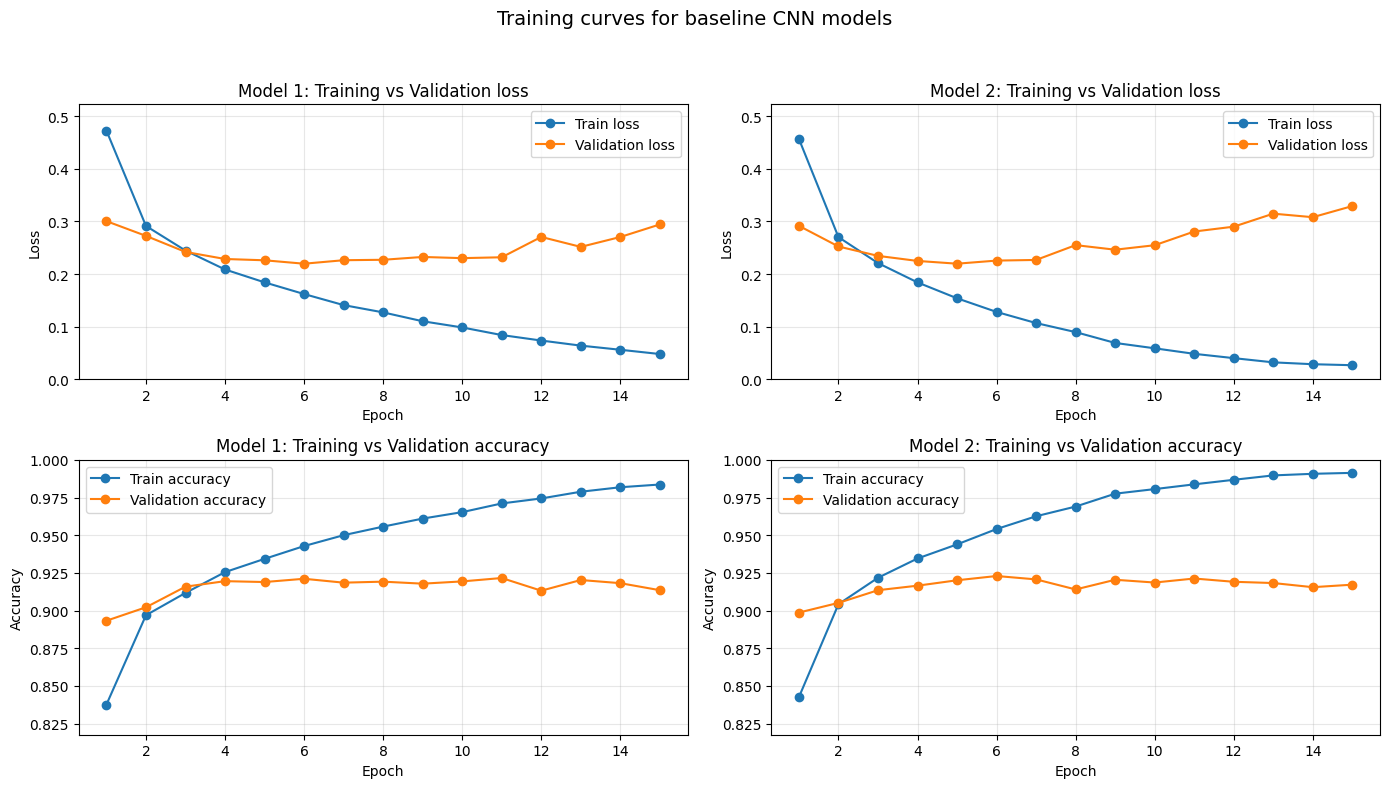

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Model 1 - loss
axes[0, 0].plot(
    history_model_1["epoch"],
    history_model_1["train_loss"],
    marker="o",
    label="Train loss"
)

axes[0, 0].plot(
    history_model_1["epoch"],
    history_model_1["val_loss"],
    marker="o",
    label="Validation loss"
)

axes[0, 0].set_title("Model 1: Training vs Validation loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)


# Model 2 - loss
axes[0, 1].plot(
    history_model_2["epoch"],
    history_model_2["train_loss"],
    marker="o",
    label="Train loss"
)

axes[0, 1].plot(
    history_model_2["epoch"],
    history_model_2["val_loss"],
    marker="o",
    label="Validation loss"
)

axes[0, 1].set_title("Model 2: Training vs Validation loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)


# Model 1 - accuracy
axes[1, 0].plot(
    history_model_1["epoch"],
    history_model_1["train_accuracy"],
    marker="o",
    label="Train accuracy"
)

axes[1, 0].plot(
    history_model_1["epoch"],
    history_model_1["val_accuracy"],
    marker="o",
    label="Validation accuracy"
)

axes[1, 0].set_title("Model 1: Training vs Validation accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)


# Model 2 - accuracy
axes[1, 1].plot(
    history_model_2["epoch"],
    history_model_2["train_accuracy"],
    marker="o",
    label="Train accuracy"
)

axes[1, 1].plot(
    history_model_2["epoch"],
    history_model_2["val_accuracy"],
    marker="o",
    label="Validation accuracy"
)

axes[1, 1].set_title("Model 2: Training vs Validation accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)


# Same y-axis scale for comparable plots
loss_min = min(
    history_model_1["train_loss"].min(),
    history_model_1["val_loss"].min(),
    history_model_2["train_loss"].min(),
    history_model_2["val_loss"].min()
)

loss_max = max(
    history_model_1["train_loss"].max(),
    history_model_1["val_loss"].max(),
    history_model_2["train_loss"].max(),
    history_model_2["val_loss"].max()
)

acc_min = min(
    history_model_1["train_accuracy"].min(),
    history_model_1["val_accuracy"].min(),
    history_model_2["train_accuracy"].min(),
    history_model_2["val_accuracy"].min()
)

acc_max = max(
    history_model_1["train_accuracy"].max(),
    history_model_1["val_accuracy"].max(),
    history_model_2["train_accuracy"].max(),
    history_model_2["val_accuracy"].max()
)

loss_padding = 0.05
acc_padding = 0.02

loss_ylim = (
    max(0, loss_min - loss_padding),
    loss_max + loss_padding
)

accuracy_ylim = (
    max(0, acc_min - acc_padding),
    min(1.0, acc_max + acc_padding)
)

axes[0, 0].set_ylim(loss_ylim)
axes[0, 1].set_ylim(loss_ylim)

axes[1, 0].set_ylim(accuracy_ylim)
axes[1, 1].set_ylim(accuracy_ylim)


plt.suptitle("Training curves for baseline CNN models", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

<div style="font-size: 16px;">

* The training curves show that both custom CNN models learn the training data very well, as the training loss decreases steadily across epochs.
* However, the validation loss starts to increase after a few epochs, which suggests overfitting.
* This effect is stronger for the deeper CNN model (Model 2).
* Although the deeper architecture achieves a lower training loss, its validation loss increases more clearly, meaning that the additional convolutional layers may make the model more prone to memorizing the training data.

<div style="font-size: 16px;">

## Custom CNN training with early stopping

Because of this, I decided to apply two regularization improvements in the next experiment:

1. I increased the dropout rate. Dropout randomly disables part of the neurons during training, which makes the model less dependent on specific connections and can help reduce overfitting.

2. I added early stopping. Early stopping monitors the validation loss and stops training when the model no longer improves. It also keeps the best model weights, so the final model is not necessarily the one from the last epoch, but the one that performed best on validation data.

Both custom CNN models were trained with the same setup: Adam optimizer, learning rate of 0.0001, batch size of 64, dropout rate of 0.4, and maximum 15 epochs. Early stopping was used with patience equal to 3, which means that training stops if validation loss does not improve for 3 consecutive epochs.

The first model uses a simpler 32 → 64 → 128 structure, while the second model uses a deeper 32 → 32 → 64 → 64 → 128 structure. This comparison helps to check whether additional convolutional layers improve classification performance or only increase the risk of overfitting.

In [25]:
DROPOUT_ES = 0.4
PATIENCE = 3

In [26]:
def train_model_early_stopping(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=15,
    patience=3
):
    history = []
    
    best_val_loss = float("inf")
    best_model_weights = copy.deepcopy(model.state_dict())
    best_epoch = 0
    
    epochs_without_improvement = 0
    
    for epoch in range(epochs):
        model.train()
        
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
            
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)
        
        train_loss = train_loss / train_total
        train_acc = train_correct / train_total
        
        model.eval()
        
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        
        val_loss = val_loss / val_total
        val_acc = val_correct / val_total
        
        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc
        })
        
        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Train acc: {train_acc:.4f} | "
            f"Val loss: {val_loss:.4f} | "
            f"Val acc: {val_acc:.4f}"
        )
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break
    
    model.load_state_dict(best_model_weights)
    print(f"Best model from epoch {best_epoch} with validation loss: {best_val_loss:.4f}")
    
    return model, pd.DataFrame(history)

In [27]:
set_seed(SEED)

model_1_es = CustomCNN_1(
    num_classes=NUM_CLASSES,
    dropout_rate=DROPOUT_ES
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer_1 = torch.optim.Adam(
    model_1_es.parameters(),
    lr=LEARNING_RATE
)

model_1_es, history_model_1_es = train_model_early_stopping(
    model=model_1_es,
    train_loader=train_loader_cnn,
    val_loader=val_loader_cnn,
    criterion=criterion,
    optimizer=optimizer_1,
    device=device,
    epochs=EPOCHS,
    patience=PATIENCE
)

history_model_1_es

/tmp/ipykernel_23/3800486466.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image, mode="L")


Epoch 1/15 | Train loss: 0.4980 | Train acc: 0.8287 | Val loss: 0.3289 | Val acc: 0.8792
Epoch 2/15 | Train loss: 0.3084 | Train acc: 0.8917 | Val loss: 0.2710 | Val acc: 0.9035
Epoch 3/15 | Train loss: 0.2572 | Train acc: 0.9084 | Val loss: 0.2384 | Val acc: 0.9152
Epoch 4/15 | Train loss: 0.2216 | Train acc: 0.9214 | Val loss: 0.2340 | Val acc: 0.9169
Epoch 5/15 | Train loss: 0.1981 | Train acc: 0.9297 | Val loss: 0.2290 | Val acc: 0.9187
Epoch 6/15 | Train loss: 0.1774 | Train acc: 0.9370 | Val loss: 0.2226 | Val acc: 0.9204
Epoch 7/15 | Train loss: 0.1589 | Train acc: 0.9432 | Val loss: 0.2198 | Val acc: 0.9206
Epoch 8/15 | Train loss: 0.1438 | Train acc: 0.9477 | Val loss: 0.2263 | Val acc: 0.9197
Epoch 9/15 | Train loss: 0.1263 | Train acc: 0.9552 | Val loss: 0.2283 | Val acc: 0.9207
Epoch 10/15 | Train loss: 0.1144 | Train acc: 0.9593 | Val loss: 0.2337 | Val acc: 0.9202
Early stopping at epoch 10
Best model from epoch 7 with validation loss: 0.2198


,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,0.498041,0.828667,0.328866,0.879167
1,2,0.308381,0.891667,0.270966,0.903500
2,3,0.257151,0.908375,0.238414,0.915167
3,4,0.221561,0.921375,0.233977,0.916917
4,5,0.198058,0.929729,0.228967,0.918667
5,6,0.177442,0.937021,0.222640,0.920417
6,7,0.158949,0.943187,0.219811,0.920583
7,8,0.143844,0.947667,0.226340,0.919750
8,9,0.126346,0.955208,0.228337,0.920667
9,10,0.114438,0.959271,0.233701,0.920167


In [28]:
set_seed(SEED)

model_2_es = CustomCNN_2(
    num_classes=NUM_CLASSES,
    dropout_rate=DROPOUT_ES
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer_2 = torch.optim.Adam(
    model_2_es.parameters(),
    lr=LEARNING_RATE
)

model_2_es, history_model_2_es = train_model_early_stopping(
    model=model_2_es,
    train_loader=train_loader_cnn,
    val_loader=val_loader_cnn,
    criterion=criterion,
    optimizer=optimizer_2,
    device=device,
    epochs=EPOCHS,
    patience=PATIENCE
)

history_model_2_es

/tmp/ipykernel_23/3800486466.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image, mode="L")


Epoch 1/15 | Train loss: 0.4798 | Train acc: 0.8341 | Val loss: 0.3056 | Val acc: 0.8842
Epoch 2/15 | Train loss: 0.2849 | Train acc: 0.8996 | Val loss: 0.2664 | Val acc: 0.8996
Epoch 3/15 | Train loss: 0.2329 | Train acc: 0.9173 | Val loss: 0.2398 | Val acc: 0.9138
Epoch 4/15 | Train loss: 0.1984 | Train acc: 0.9287 | Val loss: 0.2283 | Val acc: 0.9165
Epoch 5/15 | Train loss: 0.1693 | Train acc: 0.9391 | Val loss: 0.2285 | Val acc: 0.9202
Epoch 6/15 | Train loss: 0.1440 | Train acc: 0.9493 | Val loss: 0.2219 | Val acc: 0.9209
Epoch 7/15 | Train loss: 0.1195 | Train acc: 0.9574 | Val loss: 0.2425 | Val acc: 0.9189
Epoch 8/15 | Train loss: 0.0993 | Train acc: 0.9651 | Val loss: 0.2376 | Val acc: 0.9189
Epoch 9/15 | Train loss: 0.0836 | Train acc: 0.9711 | Val loss: 0.2549 | Val acc: 0.9193
Early stopping at epoch 9
Best model from epoch 6 with validation loss: 0.2219


,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,0.479844,0.834063,0.305621,0.884250
1,2,0.284894,0.899625,0.266376,0.899583
2,3,0.232938,0.917312,0.239783,0.913833
3,4,0.198421,0.928729,0.228338,0.916500
4,5,0.169255,0.939083,0.228544,0.920167
5,6,0.143982,0.949292,0.221926,0.920917
6,7,0.119492,0.957396,0.242458,0.918917
7,8,0.099347,0.965104,0.237628,0.918917
8,9,0.083641,0.971125,0.254891,0.919250


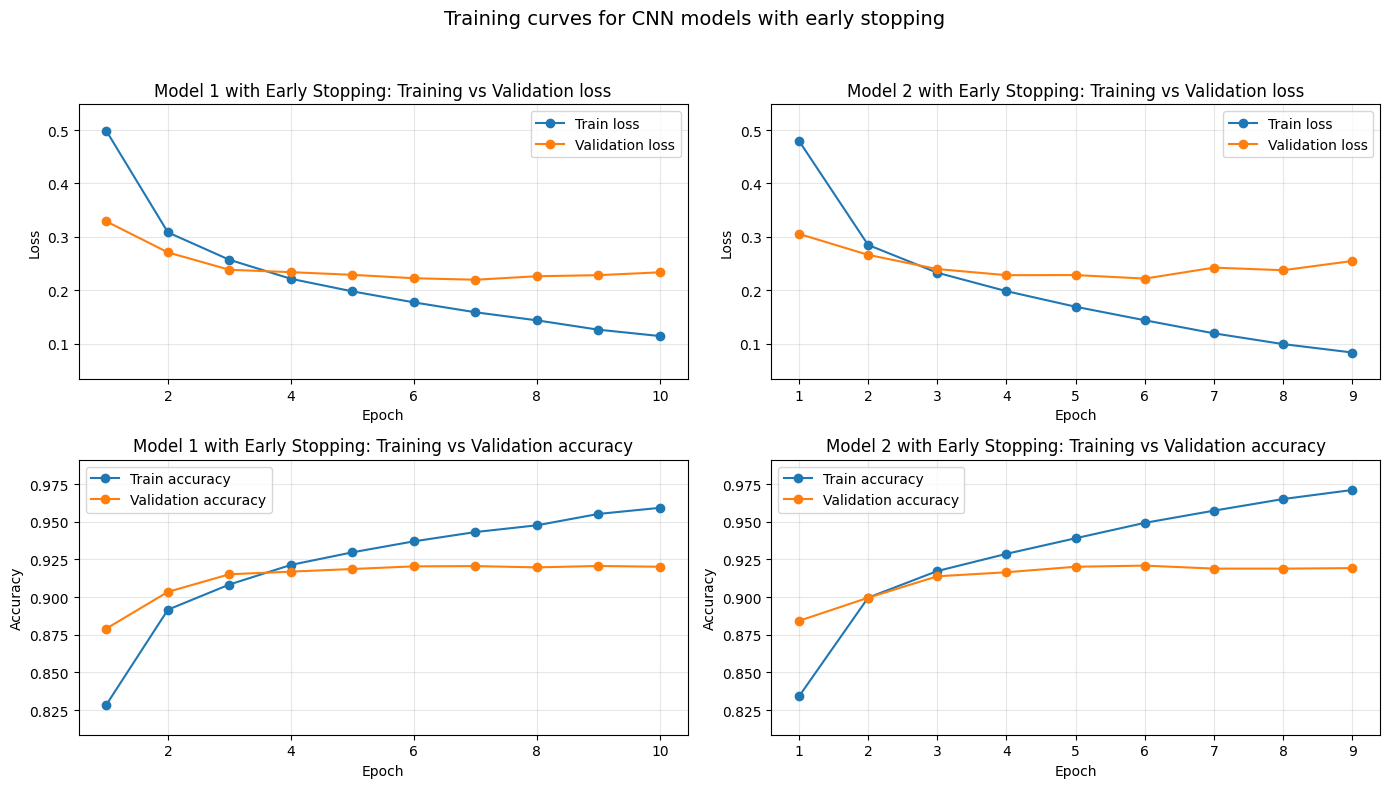

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Model 1 with early stopping - loss
axes[0, 0].plot(
    history_model_1_es["epoch"],
    history_model_1_es["train_loss"],
    marker="o",
    label="Train loss"
)

axes[0, 0].plot(
    history_model_1_es["epoch"],
    history_model_1_es["val_loss"],
    marker="o",
    label="Validation loss"
)

axes[0, 0].set_title("Model 1 with Early Stopping: Training vs Validation loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)


# Model 2 with early stopping - loss
axes[0, 1].plot(
    history_model_2_es["epoch"],
    history_model_2_es["train_loss"],
    marker="o",
    label="Train loss"
)

axes[0, 1].plot(
    history_model_2_es["epoch"],
    history_model_2_es["val_loss"],
    marker="o",
    label="Validation loss"
)

axes[0, 1].set_title("Model 2 with Early Stopping: Training vs Validation loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)


# Model 1 with early stopping - accuracy
axes[1, 0].plot(
    history_model_1_es["epoch"],
    history_model_1_es["train_accuracy"],
    marker="o",
    label="Train accuracy"
)

axes[1, 0].plot(
    history_model_1_es["epoch"],
    history_model_1_es["val_accuracy"],
    marker="o",
    label="Validation accuracy"
)

axes[1, 0].set_title("Model 1 with Early Stopping: Training vs Validation accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)


# Model 2 with early stopping - accuracy
axes[1, 1].plot(
    history_model_2_es["epoch"],
    history_model_2_es["train_accuracy"],
    marker="o",
    label="Train accuracy"
)

axes[1, 1].plot(
    history_model_2_es["epoch"],
    history_model_2_es["val_accuracy"],
    marker="o",
    label="Validation accuracy"
)

axes[1, 1].set_title("Model 2 with Early Stopping: Training vs Validation accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)


# Same y-axis scale for comparable plots
loss_min = min(
    history_model_1_es["train_loss"].min(),
    history_model_1_es["val_loss"].min(),
    history_model_2_es["train_loss"].min(),
    history_model_2_es["val_loss"].min()
)

loss_max = max(
    history_model_1_es["train_loss"].max(),
    history_model_1_es["val_loss"].max(),
    history_model_2_es["train_loss"].max(),
    history_model_2_es["val_loss"].max()
)

acc_min = min(
    history_model_1_es["train_accuracy"].min(),
    history_model_1_es["val_accuracy"].min(),
    history_model_2_es["train_accuracy"].min(),
    history_model_2_es["val_accuracy"].min()
)

acc_max = max(
    history_model_1_es["train_accuracy"].max(),
    history_model_1_es["val_accuracy"].max(),
    history_model_2_es["train_accuracy"].max(),
    history_model_2_es["val_accuracy"].max()
)

loss_padding = 0.05
acc_padding = 0.02

loss_ylim = (
    max(0, loss_min - loss_padding),
    loss_max + loss_padding
)

accuracy_ylim = (
    max(0, acc_min - acc_padding),
    min(1.0, acc_max + acc_padding)
)

axes[0, 0].set_ylim(loss_ylim)
axes[0, 1].set_ylim(loss_ylim)

axes[1, 0].set_ylim(accuracy_ylim)
axes[1, 1].set_ylim(accuracy_ylim)


plt.suptitle("Training curves for CNN models with early stopping", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Comparison best model

,model,best_epoch,best_val_loss,val_accuracy_at_best_loss
0,Model 1,6.0,0.219577,0.921083
1,Model 2,5.0,0.219611,0.920083


,model,best_epoch,best_val_loss,val_accuracy_at_best_loss
0,Model 1,7.0,0.219811,0.920583
1,Model 2,6.0,0.221926,0.920917


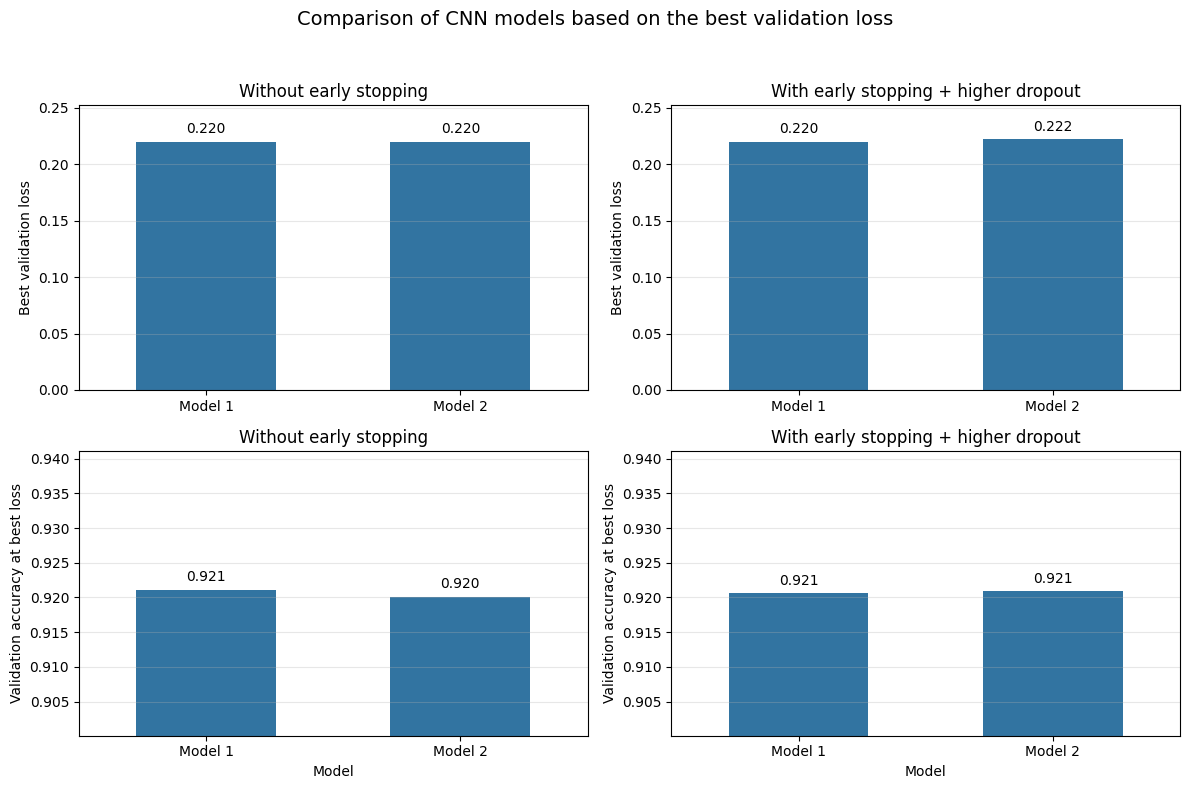

In [30]:
best_model_1 = history_model_1.loc[history_model_1["val_loss"].idxmin()]
best_model_2 = history_model_2.loc[history_model_2["val_loss"].idxmin()]

best_model_1_es = history_model_1_es.loc[history_model_1_es["val_loss"].idxmin()]
best_model_2_es = history_model_2_es.loc[history_model_2_es["val_loss"].idxmin()]


comparison_base = pd.DataFrame({
    "model": ["Model 1", "Model 2"],
    "best_epoch": [
        best_model_1["epoch"],
        best_model_2["epoch"]
    ],
    "best_val_loss": [
        best_model_1["val_loss"],
        best_model_2["val_loss"]
    ],
    "val_accuracy_at_best_loss": [
        best_model_1["val_accuracy"],
        best_model_2["val_accuracy"]
    ]
})

comparison_es = pd.DataFrame({
    "model": ["Model 1", "Model 2"],
    "best_epoch": [
        best_model_1_es["epoch"],
        best_model_2_es["epoch"]
    ],
    "best_val_loss": [
        best_model_1_es["val_loss"],
        best_model_2_es["val_loss"]
    ],
    "val_accuracy_at_best_loss": [
        best_model_1_es["val_accuracy"],
        best_model_2_es["val_accuracy"]
    ]
})

display(comparison_base)
display(comparison_es)


fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Row 1: validation loss
sns.barplot(
    data=comparison_base,
    x="model",
    y="best_val_loss",
    ax=axes[0, 0],
    width=0.55
)
axes[0, 0].set_title("Without early stopping")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Best validation loss")

sns.barplot(
    data=comparison_es,
    x="model",
    y="best_val_loss",
    ax=axes[0, 1],
    width=0.55
)
axes[0, 1].set_title("With early stopping + higher dropout")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Best validation loss")


# Row 2: validation accuracy from the same epoch as best validation loss
sns.barplot(
    data=comparison_base,
    x="model",
    y="val_accuracy_at_best_loss",
    ax=axes[1, 0],
    width=0.55
)
axes[1, 0].set_title("Without early stopping")
axes[1, 0].set_xlabel("Model")
axes[1, 0].set_ylabel("Validation accuracy at best loss")

sns.barplot(
    data=comparison_es,
    x="model",
    y="val_accuracy_at_best_loss",
    ax=axes[1, 1],
    width=0.55
)
axes[1, 1].set_title("With early stopping + higher dropout")
axes[1, 1].set_xlabel("Model")
axes[1, 1].set_ylabel("Validation accuracy at best loss")


# Same y-axis scale for comparable plots
loss_max = max(
    comparison_base["best_val_loss"].max(),
    comparison_es["best_val_loss"].max()
)

acc_min = min(
    comparison_base["val_accuracy_at_best_loss"].min(),
    comparison_es["val_accuracy_at_best_loss"].min()
)

acc_max = max(
    comparison_base["val_accuracy_at_best_loss"].max(),
    comparison_es["val_accuracy_at_best_loss"].max()
)

loss_ylim = (0, loss_max + 0.03)
accuracy_ylim = (
    max(0.80, acc_min - 0.02),
    min(1.0, acc_max + 0.02)
)

axes[0, 0].set_ylim(loss_ylim)
axes[0, 1].set_ylim(loss_ylim)

axes[1, 0].set_ylim(accuracy_ylim)
axes[1, 1].set_ylim(accuracy_ylim)


# Add values above bars
for ax in axes.flat:
    if "accuracy" in ax.get_ylabel().lower():
        value_format = "{:.3f}"
    else:
        value_format = "{:.3f}"
    
    ax.grid(axis="y", alpha=0.3)
    
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            value_format.format(height),
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 4),
            textcoords="offset points"
        )

plt.suptitle("Comparison of CNN models based on the best validation loss", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

<div style="font-size: 16px;">

### CNN model comparison conclusions

- All CNN models achieved very similar validation results.

- The differences between the baseline models and the models with early stopping and higher dropout are very small.

- The lowest validation loss was achieved by the baseline Model 1, but the difference compared to the other models is minimal.

- Early stopping and higher dropout did not clearly improve validation performance in this experiment.

- However, early stopping is still useful because it helps stop training when validation loss stops improving and restores the model from the best epoch.

- Since the results are very close, I selected the baseline Model 1 as the final CNN model because it achieved the lowest validation loss and has a simpler architecture.

# Final Test Set Evaluation (Custom CNN)

In [31]:
# Final evaluation of the best custom CNN model on the test set

best_custom_cnn = model_1

best_custom_cnn.eval()

test_loss = 0
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader_cnn:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = best_custom_cnn(images)
        loss = criterion(outputs, labels)
        
        test_loss += loss.item() * images.size(0)
        
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss = test_loss / total
test_accuracy = correct / total

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

/tmp/ipykernel_23/3800486466.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image, mode="L")


Test loss: 0.2967
Test accuracy: 0.9136


In [32]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1000
           1       1.00      0.98      0.99      1000
           2       0.90      0.87      0.88      1000
           3       0.86      0.97      0.91      1000
           4       0.94      0.79      0.86      1000
           5       0.96      0.99      0.98      1000
           6       0.72      0.83      0.77      1000
           7       0.98      0.92      0.95      1000
           8       0.98      0.98      0.98      1000
           9       0.94      0.98      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.92      0.91      0.91     10000
weighted avg       0.92      0.91      0.91     10000



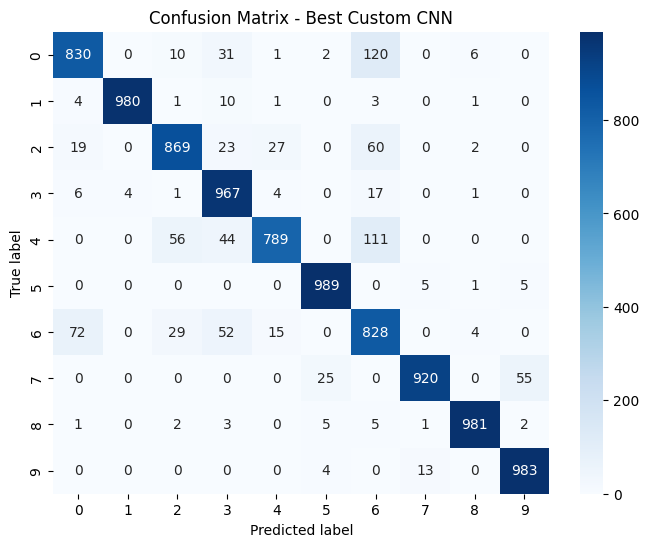

In [33]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Best Custom CNN")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.show()

    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"

<div style="font-size: 16px;">

## Conclusions

- The selected custom CNN model achieved strong results on the test set, with test accuracy equal to **0.91** and test loss equal to **0.29**.
- The model performs especially well for classes **1, 5, 7, 8 and 9**, where precision and recall are very high.
- The weakest result appears for class **4**, where recall is only **0.79**. This means that many true examples from this class were classified as other categories.
- The confusion matrix confirms that class **4** is often confused with class **6**. This may suggest that these clothing categories have visually similar shapes or textures.
- Some confusion is also visible between classes **0, 2 and 6**, which is expected in Fashion MNIST because several clothing items can have similar outlines.
- The macro average and weighted average F1-score are both around **0.91**, which shows that the model performs well across all classes, not only on the easiest ones.
- Based on these results, the custom CNN can be treated as a strong baseline model for this project.

 # Pretrained VGG16 model

<div style="font-size: 16px;">

The next step is to compare Custom CNN with the pretrained VGG16 model and check whether transfer learning can improve the final performance.


I tested a pretrained VGG16 model using PyTorch.  
Unlike the custom CNN models, VGG16 was not trained from scratch. It was first trained on a large image dataset, so it already learned many general visual patterns, such as edges, shapes and textures.

The goal of this experiment was to check whether transfer learning can improve the classification results compared to a custom CNN trained only on Fashion MNIST.

VGG16 is a deep convolutional neural network. It consists of many convolutional layers followed by fully connected layers. The convolutional part works as a feature extractor, while the final classifier is responsible for assigning the image to one of the output classes.

Since Fashion MNIST has 10 classes, I replaced the original final classification layer with a new linear layer that returns 10 outputs. The original VGG16 model was trained for 1000 ImageNet classes, so this last layer had to be adjusted to the current task.

I also froze the convolutional feature extractor. This means that the pretrained convolutional layers were not updated during training. Only the classifier part was trained on Fashion MNIST. This approach makes training faster and reduces the risk of overfitting, especially when working with a smaller dataset.

The input images also had to be adjusted to the format expected by VGG16. Fashion MNIST images are grayscale and have size 28x28, while VGG16 expects 3-channel images with size 224x224. Because of that, I converted the images to RGB, resized them to 224x224 and normalized them using ImageNet mean and standard deviation values.

In [34]:
train_dataset_vgg = FashionMNISTCSV(train_data, transform=transform_vgg)
val_dataset_vgg = FashionMNISTCSV(val_data, transform=transform_vgg)
test_dataset_vgg = FashionMNISTCSV(test_df, transform=transform_vgg)

In [35]:
train_loader_vgg = DataLoader(
    train_dataset_vgg,
    batch_size=32,
    shuffle=True
)

val_loader_vgg = DataLoader(
    val_dataset_vgg,
    batch_size=32,
    shuffle=False
)

test_loader_vgg = DataLoader(
    test_dataset_vgg,
    batch_size=32,
    shuffle=False
)

In [36]:
vgg16_model = models.vgg16(weights=VGG16_Weights.DEFAULT)

for param in vgg16_model.features.parameters():
    param.requires_grad = False

vgg16_model.classifier[6] = nn.Linear(
    in_features=4096,
    out_features=10
)

vgg16_model = vgg16_model.to(device)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 164MB/s]


In [37]:
criterion = nn.CrossEntropyLoss()

optimizer_vgg = optim.Adam(
    filter(lambda p: p.requires_grad, vgg16_model.parameters()),
    lr=0.0001
)

<div style="font-size: 16px;">

## VGG16 setup

- Model: pretrained VGG16 from PyTorch
- Pretrained weights: ImageNet weights
- Input image size: 224x224
- Number of input channels: 3
- Original Fashion MNIST images: grayscale 28x28
- Image preprocessing: grayscale images converted to RGB and resized to 224x224
- Normalization: ImageNet mean and standard deviation
- Feature extractor: frozen
- Final classifier layer: replaced with a new linear layer for 10 classes
- Number of output classes: 10
- Loss function: CrossEntropyLoss
- Optimizer: Adam
- Learning rate: 0.0001
- Training strategy: early stopping based on validation loss

In [38]:
vgg16_model, history_vgg16 = train_model_early_stopping(
    model=vgg16_model,
    train_loader=train_loader_vgg,
    val_loader=val_loader_vgg,
    criterion=criterion,
    optimizer=optimizer_vgg,
    epochs=10,
    patience=3,
    device=device
)

/tmp/ipykernel_23/3800486466.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image, mode="L")


Epoch 1/10 | Train loss: 0.3344 | Train acc: 0.8821 | Val loss: 0.2373 | Val acc: 0.9139
Epoch 2/10 | Train loss: 0.2090 | Train acc: 0.9235 | Val loss: 0.2219 | Val acc: 0.9209
Epoch 3/10 | Train loss: 0.1606 | Train acc: 0.9409 | Val loss: 0.2319 | Val acc: 0.9218
Epoch 4/10 | Train loss: 0.1259 | Train acc: 0.9547 | Val loss: 0.2280 | Val acc: 0.9223
Epoch 5/10 | Train loss: 0.0979 | Train acc: 0.9641 | Val loss: 0.2301 | Val acc: 0.9283
Early stopping at epoch 5
Best model from epoch 2 with validation loss: 0.2219


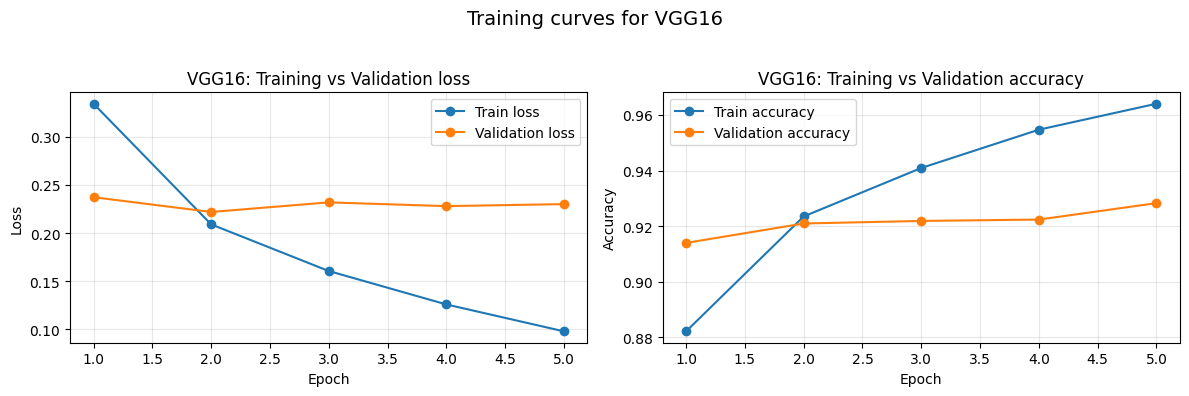

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# VGG16 - loss
axes[0].plot(
    history_vgg16["epoch"],
    history_vgg16["train_loss"],
    marker="o",
    label="Train loss"
)

axes[0].plot(
    history_vgg16["epoch"],
    history_vgg16["val_loss"],
    marker="o",
    label="Validation loss"
)

axes[0].set_title("VGG16: Training vs Validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)


# VGG16 - accuracy
axes[1].plot(
    history_vgg16["epoch"],
    history_vgg16["train_accuracy"],
    marker="o",
    label="Train accuracy"
)

axes[1].plot(
    history_vgg16["epoch"],
    history_vgg16["val_accuracy"],
    marker="o",
    label="Validation accuracy"
)

axes[1].set_title("VGG16: Training vs Validation accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)


plt.suptitle("Training curves for VGG16", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [40]:
# Final evaluation of VGG16 on the test set

vgg16_model.eval()

test_loss_vgg = 0.0
correct_vgg = 0
total_vgg = 0

all_preds_vgg = []
all_labels_vgg = []

with torch.no_grad():
    for images, labels in test_loader_vgg:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = vgg16_model(images)
        loss = criterion(outputs, labels)
        
        test_loss_vgg += loss.item() * images.size(0)
        
        _, predicted = torch.max(outputs, 1)
        total_vgg += labels.size(0)
        correct_vgg += (predicted == labels).sum().item()
        
        all_preds_vgg.extend(predicted.cpu().numpy())
        all_labels_vgg.extend(labels.cpu().numpy())

test_loss_vgg = test_loss_vgg / total_vgg
test_accuracy_vgg = correct_vgg / total_vgg

print(f"VGG16 test loss: {test_loss_vgg:.4f}")
print(f"VGG16 test accuracy: {test_accuracy_vgg:.4f}")

/tmp/ipykernel_23/3800486466.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image, mode="L")


VGG16 test loss: 0.2071
VGG16 test accuracy: 0.9248


In [41]:
print(classification_report(all_labels_vgg, all_preds_vgg))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1000
           1       0.99      0.99      0.99      1000
           2       0.95      0.83      0.89      1000
           3       0.90      0.94      0.92      1000
           4       0.85      0.94      0.90      1000
           5       0.98      0.97      0.98      1000
           6       0.79      0.74      0.77      1000
           7       0.95      0.97      0.96      1000
           8       0.99      0.99      0.99      1000
           9       0.97      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.93      0.92      0.92     10000
weighted avg       0.93      0.92      0.92     10000



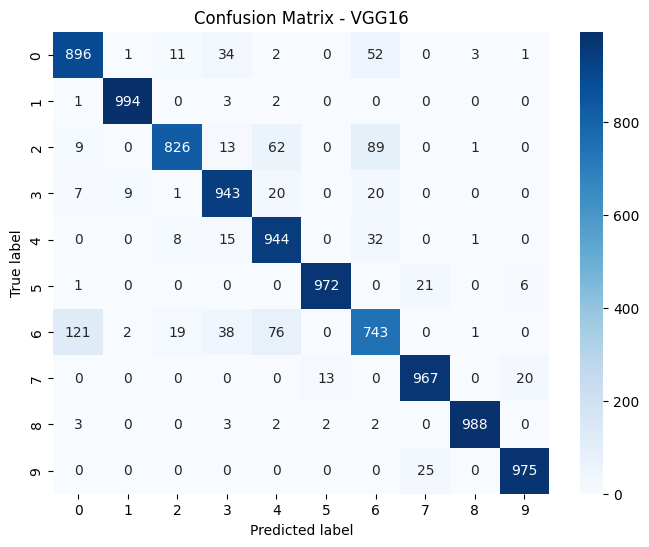

In [42]:
cm_vgg = confusion_matrix(all_labels_vgg, all_preds_vgg)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_vgg,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - VGG16")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.show()

In [43]:
test_comparison = pd.DataFrame({
    "model": ["Selected CNN - Model 1", "VGG16"],
    "test_loss": [test_loss, test_loss_vgg],
    "test_accuracy": [test_accuracy, test_accuracy_vgg]
})

test_comparison

,model,test_loss,test_accuracy
0,Selected CNN - Model 1,0.296652,0.9136
1,VGG16,0.207073,0.9248


<div style="font-size: 16px;">

## Conclusions

- VGG16 achieved better results on the test set than the selected custom CNN.

- However, the improvement in accuracy is not very large.

- Even though the test accuracy of both models is quite similar, VGG16 achieved a much lower test loss. This is important because loss does not only show whether the prediction was correct, but also how confident the model was. A lower loss suggests that VGG16 made more reliable predictions on the test set.

- The confusion matrix and classification report show that VGG16 performs very well for classes such as 1, 5, 7, 8 and 9.

- The weakest class is still class 6, with recall equal to 0.74. This means that many true examples from class 6 were classified as other visually similar classes.

- The main confusion appears between class 6 and class 0, and also class 4. This is understandable, because these clothing categories can have similar shapes.

- Overall, VGG16 achieved the best final test performance, but it is also a much larger and more computationally expensive model. The custom CNN remains a simpler and more efficient solution with competitive results.

<div style="font-size: 16px;">

# References

During this project, I drew inspiration from several high-quality Kaggle notebooks and other sources. In particular, I found the following resources especially valuable:
1. https://www.youtube.com/watch?v=HGwBXDKFk9I&list=PLblh5JKOoLUIxGDQs4LFFD--41Vzf-ME1&index=14
2. https://www.kaggle.com/code/pankajj/fashion-mnist-with-pytorch-93-accuracy
3. https://www.kaggle.com/code/mishki/getting-started-with-deep-learning-cnn-pytorch?utm_source=chatgpt.com

